<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Lan%C3%A7amentos_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas Phyton

In [1]:
!pip install unidecode wordcloud seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.8 MB/s eta 0:00:00


In [2]:
#Carrega Bibliotecas
import pandas as pd
import numpy as np
import re
from unidecode import unidecode
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import math


# Fazer Upload planilhas
1.   Lançamentos
2.   Inci
3.   Vendas

In [3]:
#Lançamentos
from google.colab import files
uploaded = files.upload()

Saving Lançamentos Jan Abr 2026.xlsx to Lançamentos Jan Abr 2026.xlsx


In [4]:
filename = next(iter(uploaded))

In [5]:
# INCI name produtos
from google.colab import files
inci = files.upload()

Saving inci_16_08.xlsx to inci_16_08.xlsx


In [6]:
filename2 = next(iter(inci))

In [7]:
#Vendas Distribuidores
from google.colab import files
dist = files.upload()

Saving Cópia de Focus Sales Report Q1 2026.xlsx to Cópia de Focus Sales Report Q1 2026.xlsx


In [8]:
filename4 = next(iter(dist))

# Função

In [77]:
# Função para limpar texto

def limpar(texto):
    if pd.isnull(texto):
        return []
    texto = unidecode(str(texto)).lower()
    texto = re.sub(r'\b\d{2,}\b', '', texto)
    texto = re.sub(r'[.,/\\-]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return [p for p in texto.split(' ') if p]

# Função para extrair chave representativa
def extrair_chave(palavras):
    if not palavras:
        return ''
    relevantes = [p for p in palavras if p not in PALAVRAS_IRRELEVANTES]
    if not relevantes:
        relevantes = palavras
    if len(relevantes) >= 2:
        return f"{relevantes[0]} {relevantes[1]}"
    return relevantes[0]

# Função para gerar chaves para DataFrame com fallback para valor bruto da coluna1
def gerar_chaves(df, coluna1, coluna2=None, coluna3=None):
    palavras1 = df[coluna1].apply(limpar)
    palavras2 = df[coluna2].apply(limpar) if coluna2 else pd.Series([[]] * len(df))
    palavras3 = df[coluna3].apply(limpar) if coluna3 else pd.Series([[]] * len(df))

    def chave_final(idx):
        for lista in [palavras1.iloc[idx], palavras2.iloc[idx], palavras3.iloc[idx]]:
            chave = extrair_chave(lista)
            if chave:
                return chave
        return str(df[coluna1].iloc[idx]).strip().lower()  # fallback para valor bruto da coluna1

    return pd.Series([chave_final(i) for i in range(len(df))], index=df.index)


In [78]:
def formatar_material(coluna):
    def extrair_codigo(texto):
        #Tenta extrair o padrão: 2+ letras + 1+ números
        match = re.search(r'\b([A-Za-z]{2,}\s*\d{1,})\b', texto)
        if match:
            return match.group(1).upper().strip()
    return coluna.apply(extrair_codigo)

In [79]:
#this checks if any combination of INCI as present in Ingredient
def verifica_ingrediente(formula,produto,material):
  quantidade = len(produto.difference(formula))
  if quantidade == 0:
    return material
  return None

In [80]:
#If last code is true, this returns the Descrição name
def procura_produtos(formula, produtos, materiais):
  formula = formula.copy()
  resultados = []
  for prod, mat in zip(produtos, materiais):
    resultado = verifica_ingrediente(formula, prod, mat)
    if resultado is not None:
      formula = formula.difference(prod) ## Para remover os ingredientes já encontrados numa nova busca.
      resultados.append(resultado)
  return resultados

In [81]:
# Função para sinalizar ingredientes do dictOTHERS
def sinaliza_ingredientes(x):
    ingredientes = set().union(*x)  # une todos os sets/listas de ingredientes do grupo
    encontrados = set()
    for ing in ingredientes:
        for palavra in dictOTHERS:
            if palavra.lower() in ing.lower():
                encontrados.add(ing)
    return ', '.join(sorted(encontrados))

In [82]:
#this code transpose data. Used when we bring each category and the number of lauches.
def transpor (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:[])

In [83]:

def to_set(x):
    s = set()
    for item in x:
        if isinstance(item, list):
            s.update(item)
        elif isinstance(item, str):
            s.add(item)
    return list(s)  # Retorna lista para compatibilidade com Excel


In [84]:
def transpor_2 (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:x)

In [85]:
def extrair_estado(texto):
    if pd.isnull(texto):
        return None
    texto = str(texto).strip().lower()
    # Procura por sigla
    for sigla in estados:
        if re.search(r'\b' + re.escape(sigla.lower()) + r'\b', texto):
            return sigla
    # Procura por nome do estado
    for nome, sigla in estados_nome_para_sigla.items():
        if nome in texto:
            return sigla
    return None

In [86]:
#Generate wordcloud

def ingredientes_exclusivos_por_categoria(df, categoria, coluna_ingredientes):
    df_cat = df[df['Categoria'].str.contains(categoria, case=False, na=False)]
    subcats = df_cat['Sub-Categoria'].dropna().unique()
    subcat_ingredientes = {}

    for subcat in subcats:
        formulas = df_cat.loc[
            df_cat['Sub-Categoria'] == subcat, coluna_ingredientes
        ].dropna()
        sets_ingredientes = [
            set(map(str.strip, ing.split(',')))
            for ing in formulas
            if isinstance(ing, str)
        ]
        if not sets_ingredientes:
            continue
        comuns = set.intersection(*sets_ingredientes)
        todos = set().union(*sets_ingredientes)
        exclusivos = todos - comuns
        subcat_ingredientes[subcat] = exclusivos
    if not subcat_ingredientes:
        return set()
    return set().union(*subcat_ingredientes.values())

## Ajustar % Min
def ingredientes_comuns_por_categoria(
    df, categoria, coluna_ingredientes, percentual_min=10
):
    df_cat = df[df['Categoria'].str.contains(categoria, case=False, na=False)]

    contador = Counter()
    total_formulas = 0

    for formula in df_cat[coluna_ingredientes].dropna():
        if isinstance(formula, str):
            ingredientes = {i.strip().lower() for i in formula.split(',') if i.strip()}
            contador.update(ingredientes)
            total_formulas += 1

    if total_formulas == 0:
        return []

    limite = total_formulas * (percentual_min / 100)

    return [
        ing for ing, freq in contador.items()
        if freq >= limite
    ]


def ingredientes_todos_por_categoria(df, categoria, coluna_ingredientes):
    df_cat = df[df['Categoria'].str.contains(categoria, case=False, na=False)]
    ingredientes = []

    for fórmula in df_cat[coluna_ingredientes].dropna():
        if isinstance(fórmula, str):
            ingredientes.extend(
                [i.strip() for i in fórmula.split(',') if i.strip()]
            )
    return ingredientes


# Função para gerar nuvem de palavras
def gerar_nuvem(ingredientes, categoria):
    texto = ', '.join(ingredientes)
    wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(texto)
    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuvem de Palavras - Ingredientes INCI exclusivos ({categoria})', fontsize=16)
    plt.savefig(f"nuvem_INCI_exclusivos_{categoria.lower()}.png")
    plt.show()

def normalizar_ingredientes(ingredientes, remover_extrato=True):
    ingredientes_norm = []
    for i in ingredientes:
        if not isinstance(i, str):
            continue
        texto = i.lower()
        if remover_extrato:
            texto = re.sub(r'\b(extract|extrato)\b', '', texto, flags=re.I)
        texto = re.sub(r'\s+', ' ', texto).strip()
        if texto:
            ingredientes_norm.append(texto)
    return ingredientes_norm

def classificar_ingredientes(ingredientes, termos_para_remover):
    termos_para_remover = [t.lower() for t in termos_para_remover]
    mantidos = []
    removidos = []
    for ing in ingredientes:
        if any(term in ing for term in termos_para_remover):
            removidos.append(ing)
        else:
            mantidos.append(ing)
    return mantidos, removidos


def limitar_por_percentual(lista_palavras, percentual=100):
    if percentual >= 100 or not lista_palavras:
        return lista_palavras
    contador = Counter(lista_palavras)
    palavras_ordenadas = contador.most_common()
    qtd_exibir = math.ceil(len(palavras_ordenadas) * (percentual / 100))
    palavras_filtradas = []
    for palavra, _ in palavras_ordenadas[:qtd_exibir]:
        palavras_filtradas.extend([palavra] * contador[palavra])
    return palavras_filtradas

def gerar_nuvem_categoria(
    df,
    categoria,
    coluna_ref,
    tipo='exclusivos',    # ← NOVO
    palavras_para_remover=None,
    percentual_exibicao=100
):
    if palavras_para_remover is None:
        palavras_para_remover = []

    # 🔹 escolher origem dos ingredientes
    if tipo == 'exclusivos':
        ingredientes = ingredientes_exclusivos_por_categoria(
            df, categoria, coluna_ref
        )
    elif tipo == 'comuns':
        ingredientes = ingredientes_comuns_por_categoria(
            df, categoria, coluna_ref
        )
    elif tipo == 'todos':
        ingredientes = ingredientes_todos_por_categoria(
            df, categoria, coluna_ref
        )
    else:
        raise ValueError("tipo deve ser 'exclusivos', 'comuns' ou 'todos'")

    # normalização
    ingredientes = normalizar_ingredientes(ingredientes)

    # filtros
    mantidos, _ = classificar_ingredientes(
        ingredientes, palavras_para_remover
    )

    # limitar por percentual
    mantidos = limitar_por_percentual(mantidos, percentual_exibicao)

    if not mantidos:
        print(f"⚠️ Sem dados para {categoria} – tipo={tipo}")
        return

    gerar_nuvem(mantidos, f"{categoria} ({tipo})")



#Dicionarios

In [87]:
#Dicionários
PALAVRAS_IRRELEVANTES = {
    'industria', 'comercio', 'cosmetico', 'cosmeticos', 'tecnologia', 'ltda', 'me', 'eireli', 'sa', 'cia', 'comercial', 'ind', ' e ',
    'produtos', 'servicos', 'serviço', 'do', 'da', 'de', 'dos', 'das', 'the', 'group', 'grupo',
    'inc', 'corp', 'corporation', 'associados', 'associado', 'associacao', 'associação', 'holding', 'importadora',
    'exportadora', 'importacao', 'importação', 'exportacao', 'exportação', 'distribuidora', 'distribuidor', 'fabricacao',
    'fabricante', 'comerciante', 'comercio', 'comércio', 'comercial', 'empresa', 'sociedade', 'unipessoal',
    'aerosol', 'aerossol',
}


In [88]:
# Dicionário de siglas e nomes de estados
estados = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 'CE': 'Ceará',
    'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}
# Inverte para buscar por nome também
estados_nome_para_sigla = {v.lower(): k for k, v in estados.items()}


In [89]:
#Dicionário Silicones geral
dictOTHERS = {'methicone':'1', 'Dimethicone':'1','methicone Crosspolymer':'1','methiconol':'1',
              'ylsiloxysilicate':'1', 'ylsilsesquioxane':'1', 'Disiloxane':'1', 'Silica':'1','siloxane':'1'}

In [90]:
#Dicionário de palavras a remover da coluna Ingredientes no Mintel
dictIng = {
    r'\s*and/or\s*': ',',
    r',\s*': ',',
    r'\s*,': ',',
    r'\s*\(and\)\s*': ','
}

#Analise Ferramenta de Lançamentos

In [91]:
#Carrega o banco de dados como tabela
data = '/content/'+filename
df_launches = pd.read_excel(data)
pd.options.display.max_columns = None
df_launches.nunique()

,0
Número do Produto,1115
Data de Publicação,81
Produto,790
Marca,767
Empresa,311
Categoria,3
Sub-Categoria,31
Descrição do Produto,1114
Preço por 100g/ml,835
Preço em moeda local,512


In [92]:
data = '/content/'+filename2
df_inci = pd.read_excel(data)
pd.options.display.max_columns=None
df_inci.nunique()

,0
Produto,51
Ingrediente,50
Prioridade,3


In [93]:
df_launches['Silicone'] = df_launches['Ingredients (Standard form)'].str.extract('('+'|'.join(dictOTHERS)+')',expand=False).map(dictOTHERS)
df_launches['Fabricante']= df_launches['Fabricante'].astype(str)
df_launches['Marca']= df_launches['Marca'].astype(str)
df_launches['Empresa']= df_launches['Empresa'].astype(str)
df_launches['Fabricante'] = df_launches['Fabricante'].fillna(df_launches['Empresa'])
df_launches['KeyManuf'] = gerar_chaves(df_launches, 'Fabricante', 'Empresa', 'Marca')
df_launches['KeyMarca'] = gerar_chaves(df_launches, 'Marca')
df_launches['KeyEmpresa'] = gerar_chaves(df_launches, 'Empresa')

In [94]:
#Edita tabela INCI

df_inci.dropna(inplace=True)
df_inci['Produto'] = formatar_material(df_inci['Produto'])

#Cria uma lista iterável dos ingredientes nos Produtos
df_inci['Ing'] = df_inci['Ingrediente'].str.split(', ').apply(set)
df_inci.sort_values('Prioridade', ascending=True, inplace=True)

In [95]:
# Cria coluna com produtos identificados
df_launches['Ingredients (Standard form)'] = df_launches['Ingredients (Standard form)'].astype(str)
#Cria uma lista iterável das ingredientes cosmeticos
df_launches['Ing'] = (
    df_launches['Ingredients (Standard form)']
    .replace(dictIng, regex=True)
    .str.split(',')
    .apply(set)
)

# Relaciona os ingredientes cosméticos
df_launches['Prod Ident'] = df_launches['Ing'].apply(
    lambda formulacao: procura_produtos(formulacao, df_inci['Ing'], df_inci['Produto'])
)

In [96]:
#Edita Coluna Ano
df_launches['Ano'] = pd.to_datetime(df_launches['Data de Publicação']).dt.year

## Heatmap Silicones

In [97]:

TOP_CATEGORIAS = 3      # número de categorias analisadas
TOP_SUBCATEGORIAS = 10   # limite de subcategorias no eixo X
TOP_SILICONES = 20      # silicones mais relevantes


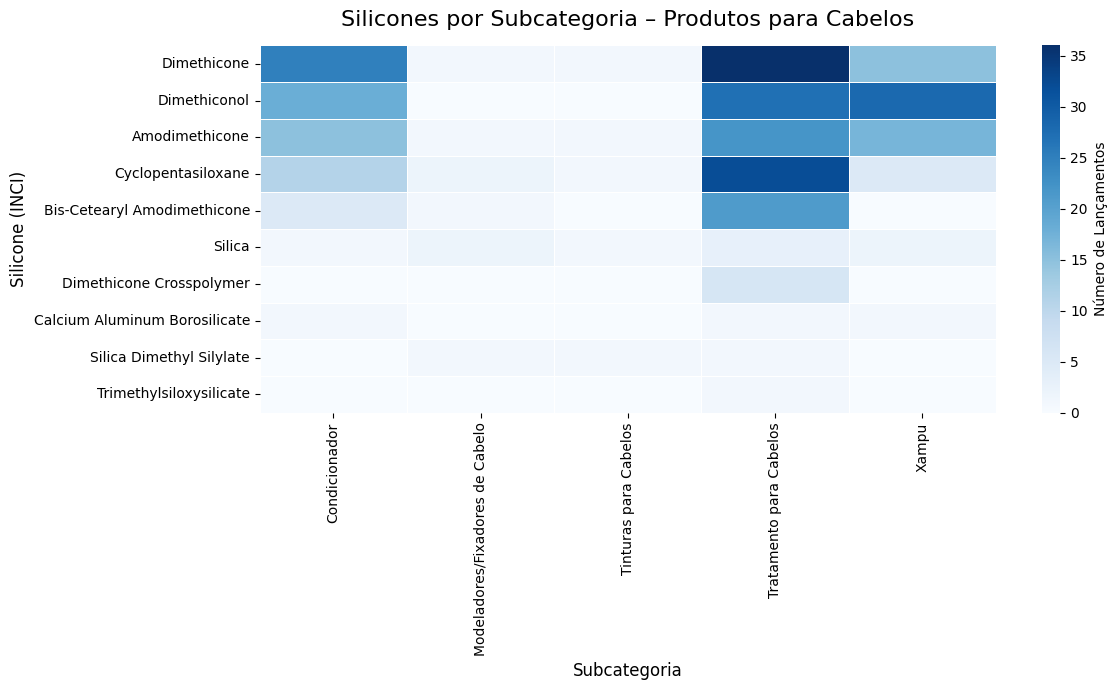

✅ Arquivo salvo: Heatmap_Silicones_Produtos_para_Cabelos.png


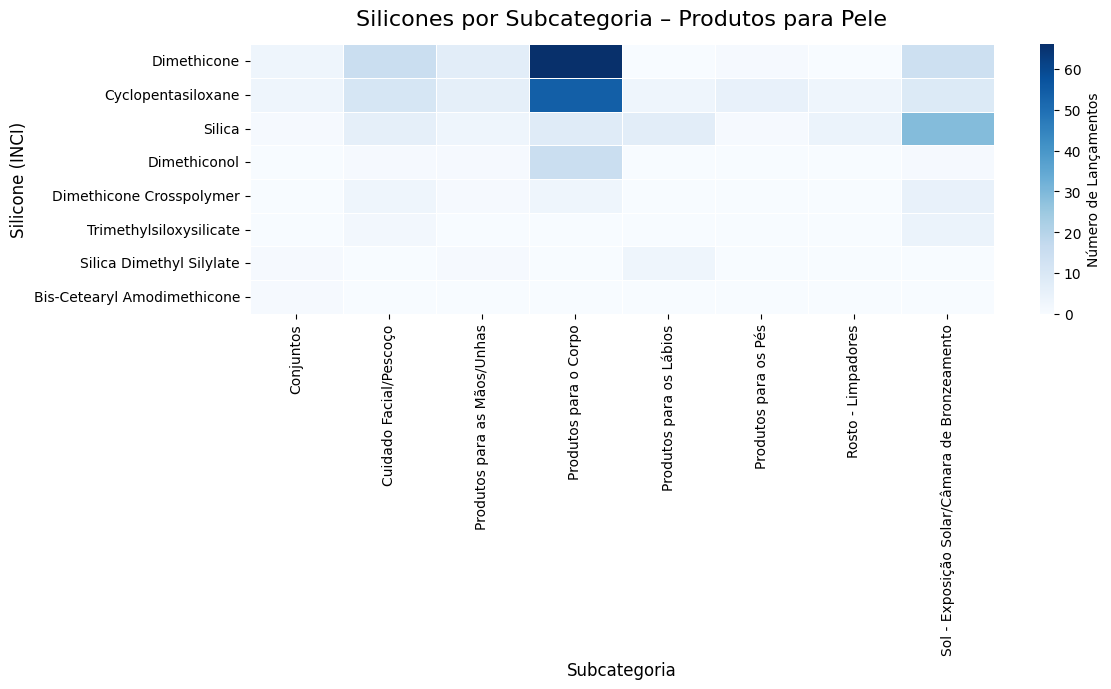

✅ Arquivo salvo: Heatmap_Silicones_Produtos_para_Pele.png


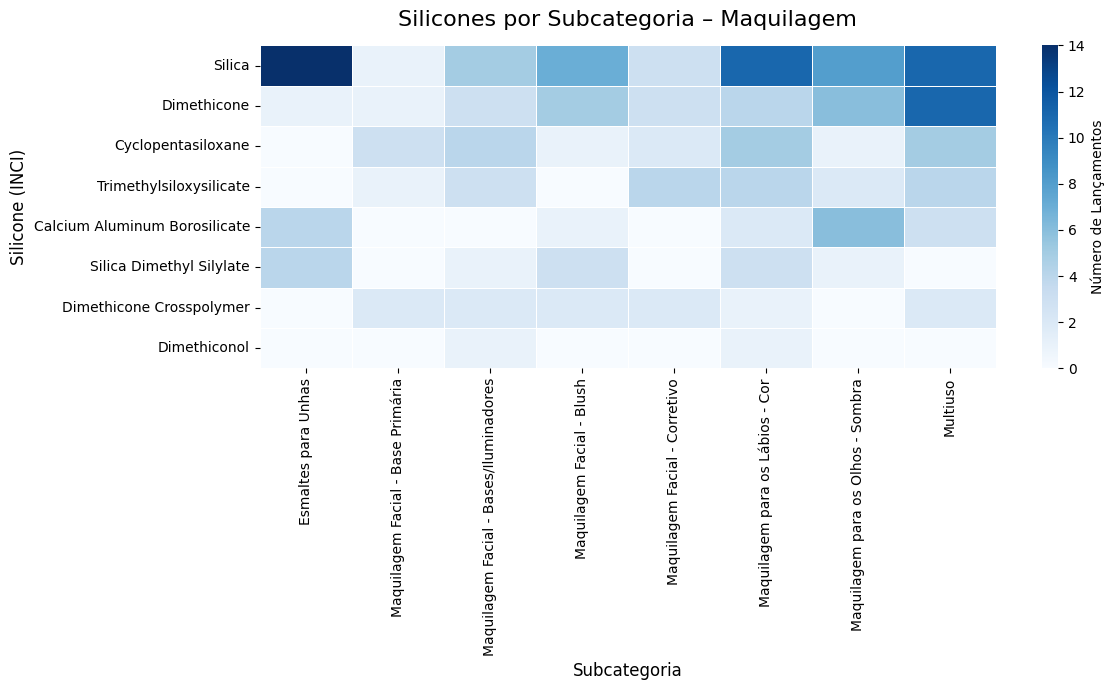

✅ Arquivo salvo: Heatmap_Silicones_Maquilagem.png


In [98]:
# ===============================
# HEATMAP DE SILICONES
# POR CATEGORIA x SUBCATEGORIA
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# PARÂMETROS
# ===============================
TOP_CATEGORIAS = 3
TOP_SUBCATEGORIAS = 8
TOP_SILICONES = 10

# ===============================
# 1. LISTA DE SILICONES
# ===============================
lista_silicones = [k.lower() for k in dictOTHERS.keys()]

# ===============================
# 2. FILTRAR INGREDIENTES SILICONADOS
# ===============================
df_silicone = df_launches.explode('Ing')

df_silicone = df_silicone[
    df_silicone['Ing']
    .astype(str)
    .str.lower()
    .str.contains('|'.join(lista_silicones), na=False)
]

# ===============================
# 3. CONTAR POR CATEGORIA / SUBCATEGORIA
# ===============================
silicone_cat = (
    df_silicone
    .groupby(['Categoria', 'Sub-Categoria', 'Ing'])
    .size()
    .reset_index(name='Contagem')
)

# ===============================
# 4. TOP SILICONES GLOBAIS
# ===============================
top_silicones = (
    silicone_cat
    .groupby('Ing')['Contagem']
    .sum()
    .sort_values(ascending=False)
    .head(TOP_SILICONES)
    .index
)

silicone_cat = silicone_cat[silicone_cat['Ing'].isin(top_silicones)]

# ===============================
# 5. TOP CATEGORIAS
# ===============================
top_categorias = (
    silicone_cat
    .groupby('Categoria')['Contagem']
    .sum()
    .sort_values(ascending=False)
    .head(TOP_CATEGORIAS)
    .index
)

# ===============================
# 6. GERAR HEATMAP POR CATEGORIA
# ===============================
for categoria in top_categorias:

    df_cat = silicone_cat[silicone_cat['Categoria'] == categoria]

    # Top subcategorias da categoria
    top_subcats = (
        df_cat
        .groupby('Sub-Categoria')['Contagem']
        .sum()
        .sort_values(ascending=False)
        .head(TOP_SUBCATEGORIAS)
        .index
    )

    df_cat = df_cat[df_cat['Sub-Categoria'].isin(top_subcats)]

    # ===============================
    # MATRIZ DO HEATMAP
    # ===============================
    heat_df = df_cat.pivot_table(
        index='Ing',
        columns='Sub-Categoria',
        values='Contagem',
        aggfunc='sum',
        fill_value=0
    )

    heat_df = heat_df.loc[
        heat_df.sum(axis=1).sort_values(ascending=False).index
    ]

    # ===============================
    # PLOT
    # ===============================
    plt.figure(figsize=(12, 7))

    sns.heatmap(
        heat_df,
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': 'Número de Lançamentos'}
    )

    plt.title(
        f'Silicones por Subcategoria – {categoria}',
        fontsize=16,
        pad=14
    )
    plt.xlabel('Subcategoria', fontsize=12)
    plt.ylabel('Silicone (INCI)', fontsize=12)

    plt.tight_layout()

    # ===============================
    # SALVAR
    # ===============================
    nome_arquivo = f"Heatmap_Silicones_{categoria.replace(' ', '_')}.png"

    plt.savefig(
        nome_arquivo,
        dpi=300,
        bbox_inches='tight'
    )


    # ✅ MOSTRAR NO OUTPUT
    plt.show()

    plt.close()

    print(f"✅ Arquivo salvo: {nome_arquivo}")


## Nuvem de palavra

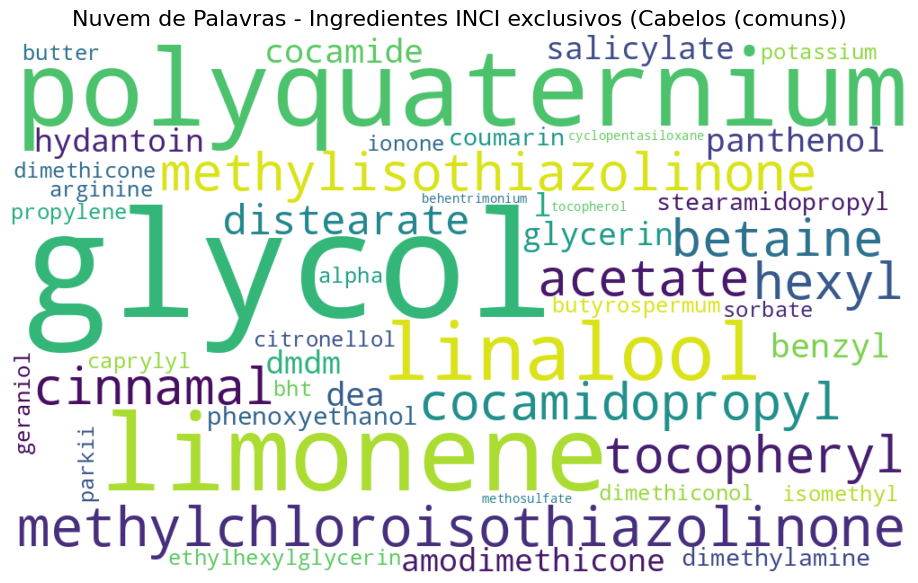

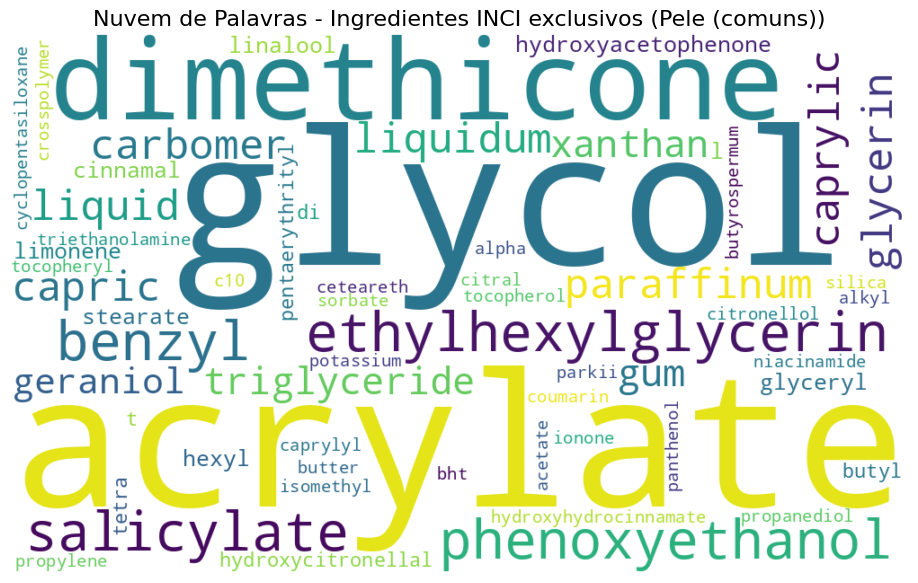

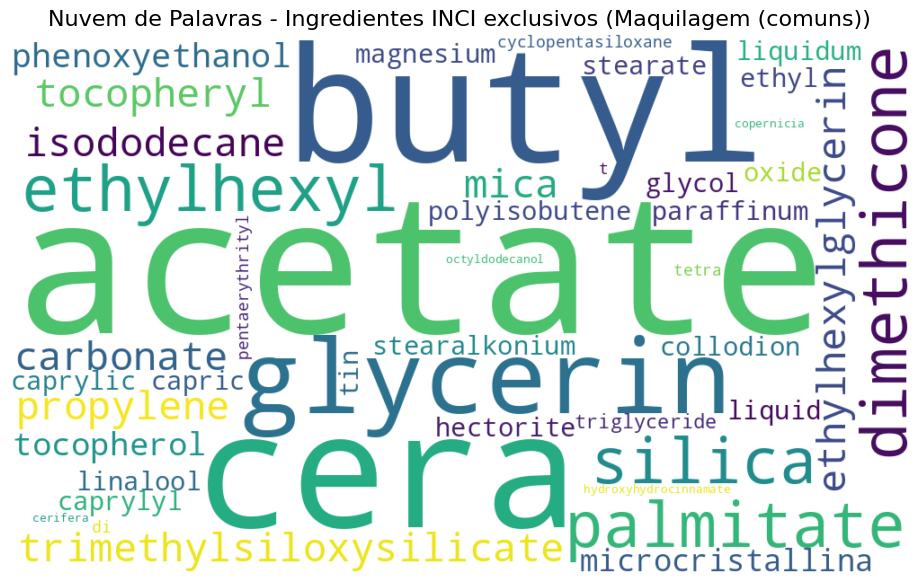

In [99]:
#Nuvem de Palavra

filtros_usuario = [
    "water",
    "aqua",
    "fragrance",
    "parfum",
    "ci ",
    "color",
    "oil",
    "perfume",
    "acid",
    "sodium",
    "chloride",
    "hydrolysed",
    "alcohol",
    "hydrogenated",
    "titanium dioxide",
    "may contain",
    "basic",
    "peg",
    "artificial",
    "synthetic"
]

# Gerar Nuvem de Palavras
coluna_ref = "Ingredients (Standard form)"

gerar_nuvem_categoria(
    df_launches,
    categoria="Cabelos",
    coluna_ref=coluna_ref,
    tipo='comuns',
    palavras_para_remover=filtros_usuario,
    percentual_exibicao=100
)

gerar_nuvem_categoria(
    df_launches,
    categoria="Pele",
    coluna_ref=coluna_ref,
    tipo='comuns',
    palavras_para_remover=filtros_usuario,
    percentual_exibicao=100
)

gerar_nuvem_categoria(
    df_launches,
    categoria="Maquilagem",
    coluna_ref=coluna_ref,
    tipo='comuns',
    palavras_para_remover=filtros_usuario,
    percentual_exibicao=100,
)

In [100]:
def contar_ingredientes_por_categoria(df):
    contagem_por_categoria = {}
    for categoria, grupo in df.groupby('Categoria'):
        contador = Counter()
        for ingredientes in grupo['Ing']:
            contador.update(ingredientes)
        contagem_por_categoria[categoria] = dict(contador)

    # Cria o DataFrame
    df_contagem = pd.DataFrame(contagem_por_categoria).fillna(0).astype(int).sort_index()

    # Adiciona a coluna de soma total por linha
    df_contagem['Total'] = df_contagem.sum(axis=1)

    return df_contagem

# Aplica e salva
tabela_ingredientes = contar_ingredientes_por_categoria(df_launches)
tabela_ingredientes.to_excel("Contagem_Todos_Ingredientes_por_categoria.xlsx")

# Análise Ferramenta de Vendas

In [101]:
data = '/content/'+filename4
df_sale = pd.read_excel(data)
pd.options.display.max_columns=None
df_sale.nunique()

,0
Distributor (subsidiary),1
WACKER Business Team Initials,1
WACKER Market Segment,0
WACKER Application,0
WACKER Material No.,63
WACKER Material Name,67
Customer No. (at distributor),0
Customer Name,1261
Corporate Group (of customer),0
Country code ship-to (of customer),1


In [102]:
# Prepara Relatório
# Limpa e padroniza a coluna 'Material'
df_sale['WACKER Material Name'] = formatar_material(df_sale['WACKER Material Name'].astype(str))
df_sale['Distributor (subsidiary)'] = df_sale['Distributor (subsidiary)'].astype(str)

# Padroniza fabricantes e distribuidores
df_sale['KeyManuf'] = gerar_chaves(df_sale, 'Customer Name')

# Preenche Estado com base na coluna de região inicialmente
df_sale['Estado'] = df_sale['Region (State/Province) ship-to (of customer)'].astype(str)

estado_por_keymanuf = (
    df_sale[df_sale['Estado'].notna() & (df_sale['Estado'] != '')]
    .groupby('KeyManuf')['Estado']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

def preencher_estado(row):
    if pd.isna(row['Estado']) or row['Estado'] == '' or row['Estado'] == 'nan':
        return estado_por_keymanuf.get(row['KeyManuf'], 'XX')
    return row['Estado']

df_sale['Estado'] = df_sale.apply(preencher_estado, axis=1)

df_final = df_sale.groupby(['KeyManuf', 'Estado']).agg(
               Distributor_Set = ('Distributor (subsidiary)', set),
               Sales_Qnty_2025 = ('WACKER Material Name', lambda x: len({str(i).strip() for i in x if pd.notnull(i)})),
               Sales_Kg_2025 = ('Quantity actual period', 'sum'),
               Sales_2025 = ('WACKER Material Name', to_set),
               )
df_final.to_excel('Resumo_vendas.xlsx')
df_final.head()


,,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
KeyManuf,Estado,,,,
&co e,SP,{FOCUS QUIMICA},4,1461.5,"[EG 5, TMS 803, DM 5, EG 6000]"
2k,SC,{FOCUS QUIMICA},1,15.0,[GB 1020]
3fa,GO,{FOCUS QUIMICA},4,1291.0,"[EG 5, OW 2100, DM 0, GB 1020]"
a &,SC,{FOCUS QUIMICA},13,15481.0,"[GB 150, EG 5, TMS 803, CM 1000, ADM 8301, DM ..."
a&s technologies,SP,{FOCUS QUIMICA},7,37782.0,"[TMS 803, DM 60000, DM 6010, DM 0, OW 2100, AK..."


#final

In [103]:
# Exemplo: supondo que sua coluna de empresa é 'Fabricante'
df_launches['Estado'] = df_launches['Manufacturer Company Address'].apply(extrair_estado)

In [104]:
# Preencher os valores ausentes de 'Estado' com base em 'KeyManuf'
missing_estado = df_launches[df_launches['Estado'].isna()]
for index, row in missing_estado.iterrows():
    keymanuf = row['KeyManuf']

    # Buscar registros com o mesmo 'KeyManuf' e 'Estado' não nulo
    estado_valido = df_launches[
        (df_launches['KeyManuf'] == keymanuf) &
        (df_launches['Estado'].notna())
    ]['Estado'].unique()

    # Se houver apenas um valor único de 'Estado', preencher
    if len(estado_valido) == 1:
        df_launches.at[index, 'Estado'] = estado_valido[0]

In [105]:
df_launches['indice']=1
transpor_2(df_launches, 'Categoria', 'indice')

In [106]:
#renomeia coluna categoria
df_launches.rename(columns={'Produtos para Pele':'Pele', 'Produtos para Cabelos':'Cabelos',
                            'Maquilagem': 'Make',
                            'Número do Produto':'Total Lançamentos'},inplace=True)

In [107]:
df_c = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False)[['Pele', 'Cabelos', 'Make']].apply(lambda x:x.count())

In [108]:
#cria tabela que lista o fabricante, o estado e o total de lançamentos, quais tem silicone,
df_b = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False).agg({
    'KeyMarca': to_set,
    'KeyEmpresa': to_set,
    'Total Lançamentos': 'count',
    'Silicone': 'count',
    'Preço por 100g/ml': 'mean',
    'Prod Ident': to_set,
    'Ing': sinaliza_ingredientes
})

In [109]:
#Une tabelas anteriores
df_launches_fab = pd.concat([df_c, df_b], axis=1).reset_index()

In [110]:
df_launches_fab.to_excel('Relatório Lançamentos.xlsx')
df_launches_fab.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Preço por 100g/ml,Prod Ident,Ing
0,&co e,SP,4,0,2,"[pinkcheeks, pinkcheeks sport, pinkcheeks pro]",[&co e],6,5,768.208333,"[TMS 803, ES 3007]","C30-45 Alkyl Methicone, Cyclopentasiloxane, Di..."
1,5 cinco,PR,1,0,0,[5 cinco],[5 cinco],1,0,72.600000,[],
2,a w,SP,0,0,3,"[simple organic, qdb pop, avon color]","[botica farmaceutica, avon, simple organic]",3,1,2269.393333,[],Silica
3,ache laboratorios,SP,0,2,0,[ache pant],[ache laboratorios],2,1,58.330000,[],Dimethicone
4,active,GO,1,2,0,[pom pom],[active],3,1,9.500000,[],Dimethiconol


In [111]:

def contar_ingredientes_por_estado(df):
    contagem_por_estado = {}
    for estado, grupo in df.groupby('Estado'):
        contador = Counter()
        for ingredientes in grupo['Ing']:
            contador.update(ingredientes)
        contagem_por_estado[estado] = dict(contador)
    return pd.DataFrame(contagem_por_estado).fillna(0).astype(int).sort_index()

# Aplica e salva
tabela_ingredientes = contar_ingredientes_por_estado(df_launches)
tabela_ingredientes.to_excel("Contagem_Todos_Ingredientes_por_Estado.xlsx")


## Agrupar relatório Vendas e Projetos

In [112]:
#agrupa lançamentos com vendas e projetos
df_launches_vend_proj = df_launches_fab.merge(df_final, on=['KeyManuf', 'Estado'], how='outer')

In [113]:

def preencher_distributor(row):
    if pd.isna(row['Distributor_Set']) or row['Distributor_Set'] == '':
        if row['Silicone'] != 0 and not pd.isna(row['Silicone']):
            return 'Competitor'
        else:
            return 'No Silicone'
    return row['Distributor_Set']

# Aplicar a função ao DataFrame
df_launches_vend_proj['Distributor_Set'] = df_launches_vend_proj.apply(preencher_distributor, axis=1)


In [114]:
df_launches_vend_proj.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Preço por 100g/ml,Prod Ident,Ing,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
0,&co e,SP,4.0,0.0,2.0,"[pinkcheeks, pinkcheeks sport, pinkcheeks pro]",[&co e],6.0,5.0,768.208333,"[TMS 803, ES 3007]","C30-45 Alkyl Methicone, Cyclopentasiloxane, Di...",{FOCUS QUIMICA},4.0,1461.5,"[EG 5, TMS 803, DM 5, EG 6000]"
1,2k,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{FOCUS QUIMICA},1.0,15.0,[GB 1020]
2,3fa,GO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{FOCUS QUIMICA},4.0,1291.0,"[EG 5, OW 2100, DM 0, GB 1020]"
3,5 cinco,PR,1.0,0.0,0.0,[5 cinco],[5 cinco],1.0,0.0,72.600000,[],,No Silicone,NaN,NaN,NaN
4,a &,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{FOCUS QUIMICA},13.0,15481.0,"[GB 150, EG 5, TMS 803, CM 1000, ADM 8301, DM ..."


# Generate a Report will all information

In [115]:
df_launches_vend_proj.to_excel('Final.xlsx')

In [116]:

# Selecionar as colunas desejadas
colunas = ['KeyManuf', 'Estado', 'Distributor_Set', 'Sales_Kg_2025', 'Sales_2025']

# Criar um novo DataFrame apenas com essas colunas
df_resumo = df_launches_vend_proj[colunas]

# Exibir as primeiras linhas
print(df_resumo.head())

# Se quiser salvar em Excel:
df_resumo.to_excel('resumo_keymanuf.xlsx', index=False)


  KeyManuf Estado  Distributor_Set  Sales_Kg_2025  \
0    &co e     SP  {FOCUS QUIMICA}         1461.5   
1       2k     SC  {FOCUS QUIMICA}           15.0   
2      3fa     GO  {FOCUS QUIMICA}         1291.0   
3  5 cinco     PR      No Silicone            NaN   
4      a &     SC  {FOCUS QUIMICA}        15481.0   

                                          Sales_2025  
0                     [EG 5, TMS 803, DM 5, EG 6000]  
1                                          [GB 1020]  
2                     [EG 5, OW 2100, DM 0, GB 1020]  
3                                                NaN  
4  [GB 150, EG 5, TMS 803, CM 1000, ADM 8301, DM ...  
